# Notebook 02: Data Simulation

We generate 10 years (120 monthly observations) of synthetic data from the true DGP:
1. VAR(1) factors → yield curves
2. Factors → deposit rates by segment

This gives us a ground truth to evaluate model recovery in notebooks 03 and 04.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from simulate import (
    simulate_all, ns_loadings,
    MATURITIES, SEGMENTS,
    TRUE_MU, TRUE_PHI, TRUE_Q,
    TRUE_ALPHA, TRUE_BETA_L, TRUE_BETA_S, TRUE_BETA_C, TRUE_SIGMA_D,
)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## 1. Simulate

In [2]:
data = simulate_all(T=120, seed=42)

factors  = data["factors"]      # (120, 3)  Level, Slope, Curvature
yields   = data["yields"]       # (120, 8)  observed yields
yields_t = data["yields_true"]  # (120, 8)  noiseless yields
deposits = data["deposits"]     # (120, 4)  deposit rates by segment

print("Sample period:", factors.index[0].date(), "to", factors.index[-1].date())
print(f"Maturities (months): {list(MATURITIES.astype(int))}")
print(f"Segments: {SEGMENTS}")
print()
print("Factor summary:")
print(factors.describe().round(3))

Sample period: 2015-01-01 to 2024-12-01
Maturities (months): [np.int64(3), np.int64(6), np.int64(12), np.int64(24), np.int64(36), np.int64(60), np.int64(84), np.int64(120)]
Segments: ['Retail Current', 'Retail Savings', 'SME Operational', 'Corporate']

Factor summary:
         Level    Slope  Curvature
count  120.000  120.000    120.000
mean     5.039   -1.505      0.919
std      0.645    0.507      0.297
min      3.083   -2.798      0.119
25%      4.724   -1.828      0.728
50%      5.004   -1.534      0.926
75%      5.390   -1.147      1.106
max      6.907   -0.465      1.596


## 2. Factor Dynamics

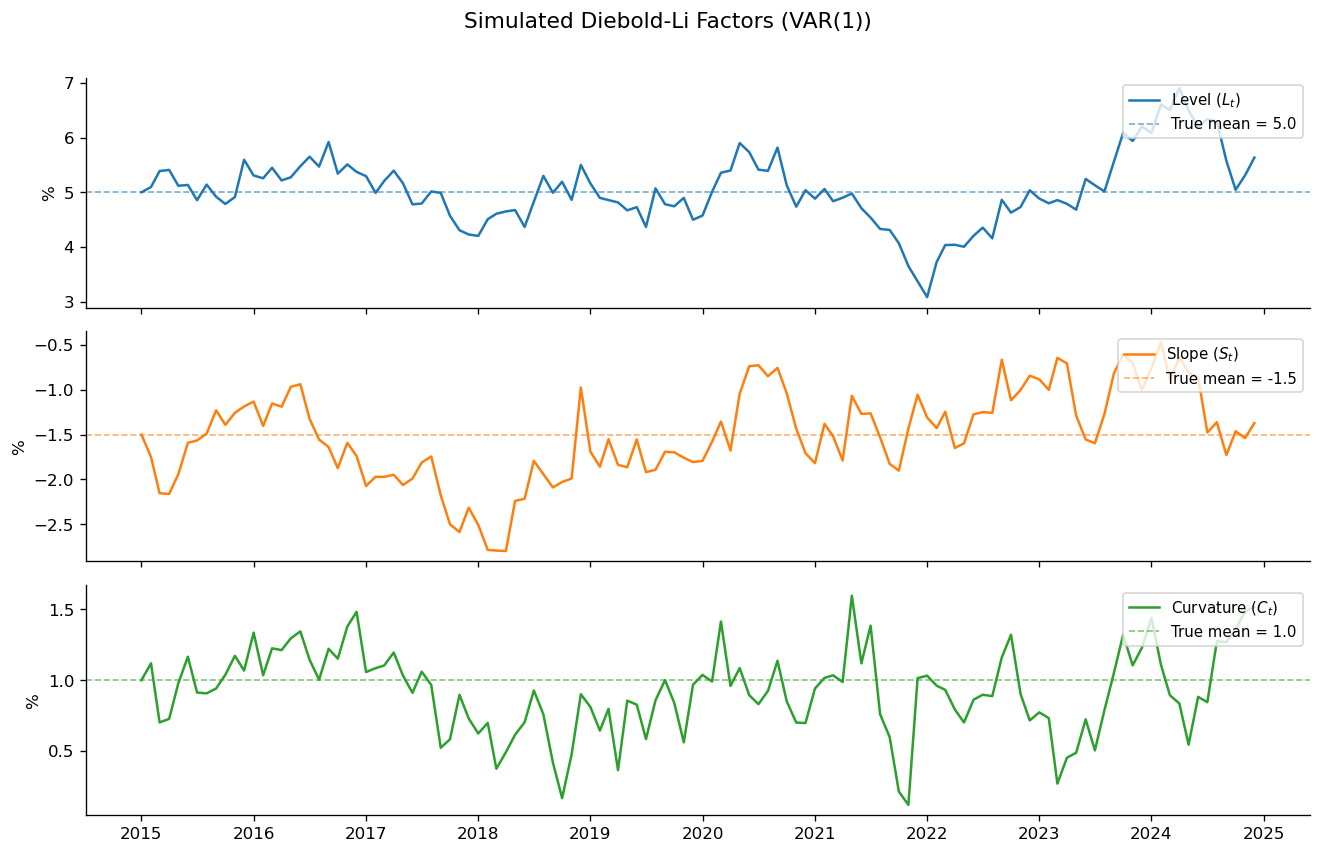

True VAR(1) diagonal (Φ): [0.95 0.9  0.85]
True long-run means (μ): [ 5.  -1.5  1. ]


In [3]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
labels = ["Level ($L_t$)", "Slope ($S_t$)", "Curvature ($C_t$)"]
true_means = TRUE_MU

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for i, (ax, col, lbl, mu) in enumerate(zip(axes, factors.columns, labels, true_means)):
    ax.plot(factors.index, factors[col], color=colors[i], lw=1.5, label=lbl)
    ax.axhline(mu, color=colors[i], lw=1.0, ls="--", alpha=0.6, label=f"True mean = {mu}")
    ax.set_ylabel("%")
    ax.legend(loc="upper right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Simulated Diebold-Li Factors (VAR(1))", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

print("True VAR(1) diagonal (Φ):", np.diag(TRUE_PHI))
print("True long-run means (μ):", TRUE_MU)

## 3. Yield Curves

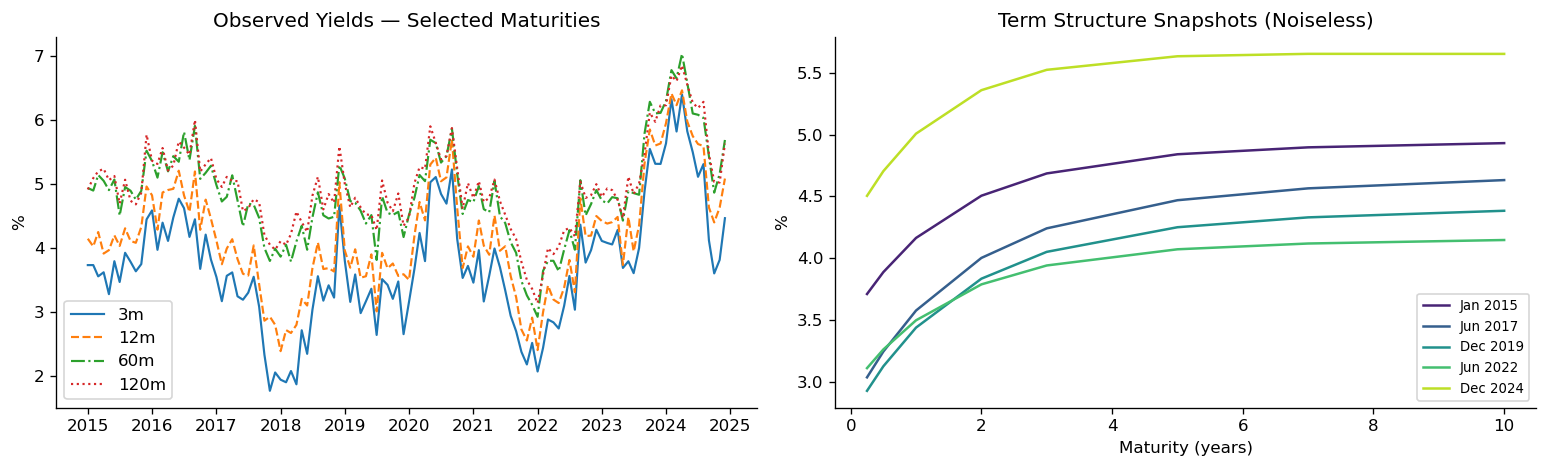

In [4]:
mat_labels = yields.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Time-series of key maturities
ax = axes[0]
for col, ls in zip(["3m", "12m", "60m", "120m"], ["-", "--", "-.", ":"]):
    ax.plot(yields.index, yields[col], lw=1.3, ls=ls, label=col)
ax.set_title("Observed Yields at selected maturities")
ax.set_ylabel("%")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Snapshot yield curves at a few dates
ax = axes[1]
snap_dates = [yields.index[0], yields.index[29], yields.index[59], yields.index[89], yields.index[-1]]
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(snap_dates)))
tau_plot = MATURITIES / 12  # convert to years for x-axis
for d, c in zip(snap_dates, cmap):
    ax.plot(tau_plot, yields_t.loc[d], color=c, lw=1.5, label=d.strftime("%b %Y"))
ax.set_title("Term Structure Snapshots (Noiseless)")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("%")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 4. Deposit Rates by Segment

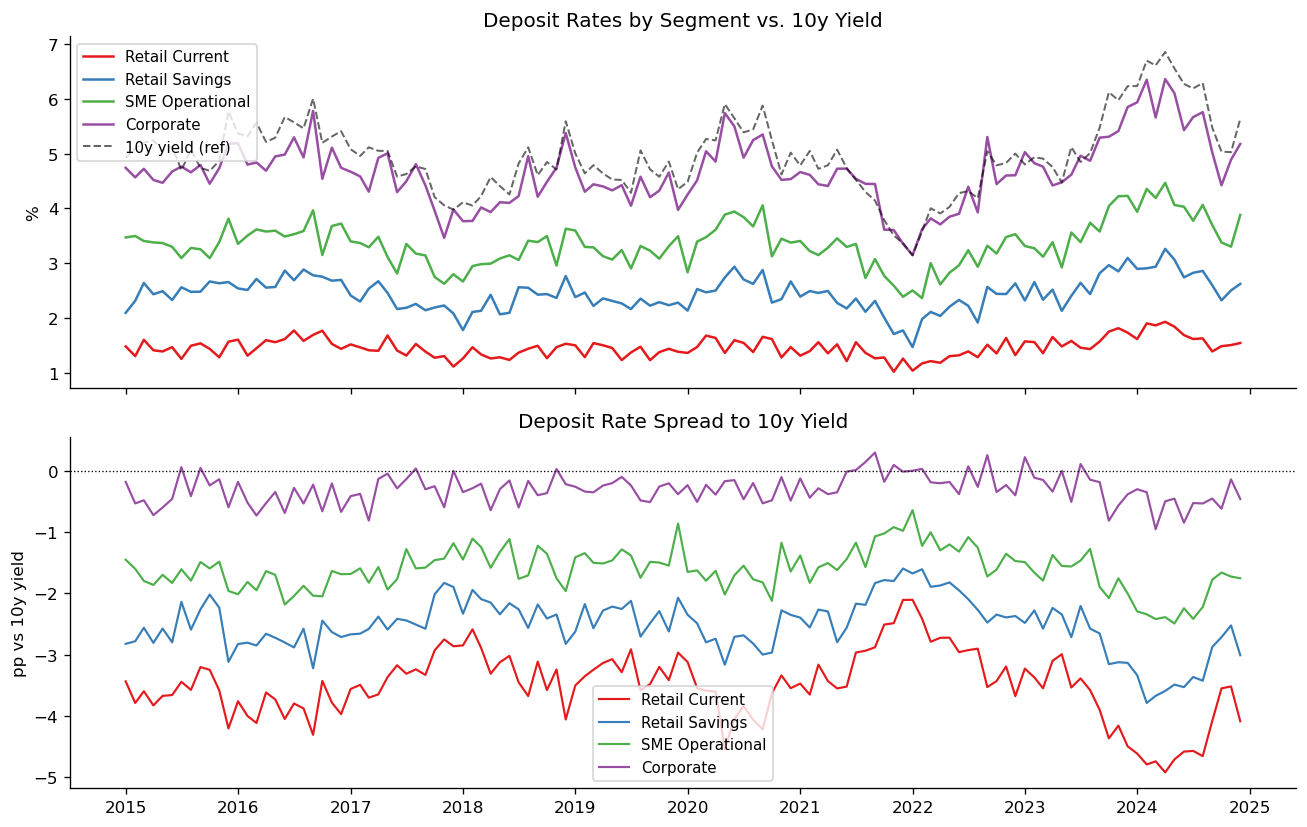

In [5]:
seg_colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Deposit rates
ax = axes[0]
for seg, c in zip(SEGMENTS, seg_colors):
    ax.plot(deposits.index, deposits[seg], color=c, lw=1.5, label=seg)
ax.plot(yields.index, yields["120m"], color="black", lw=1.2, ls="--", alpha=0.6, label="10y yield (ref)")
ax.set_ylabel("%")
ax.set_title("Deposit Rates by Segment vs. 10y Yield")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Spread to 10y yield
ax = axes[1]
for seg, c in zip(SEGMENTS, seg_colors):
    spread = deposits[seg] - yields["120m"]
    ax.plot(deposits.index, spread, color=c, lw=1.3, label=seg)
ax.axhline(0, color="black", lw=0.8, ls=":")
ax.set_ylabel("pp vs 10y yield")
ax.set_title("Deposit Rate Spread to 10y Yield")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()

## 5. True Parameters Summary

In [6]:
print("=" * 55)
print("TRUE REPRICING PARAMETERS")
print("=" * 55)
header = f"{'Segment':<20} {'α':>6} {'β_L':>6} {'β_S':>6} {'β_C':>6} {'σ':>6}"
print(header)
print("-" * 55)
for s, seg in enumerate(SEGMENTS):
    print(f"{seg:<20} {TRUE_ALPHA[s]:>6.3f} {TRUE_BETA_L[s]:>6.3f} {TRUE_BETA_S[s]:>6.3f} {TRUE_BETA_C[s]:>6.3f} {TRUE_SIGMA_D[s]:>6.3f}")
print("=" * 55)

# Save data for downstream notebooks
import pickle, os
os.makedirs("../data", exist_ok=True)
with open("../data/simulated.pkl", "wb") as f:
    pickle.dump(data, f)
print("\nData saved to ../data/simulated.pkl")

TRUE REPRICING PARAMETERS
Segment                   α    β_L    β_S    β_C      σ
-------------------------------------------------------
Retail Current        0.500  0.200  0.050  0.020  0.100
Retail Savings        0.800  0.350  0.100  0.050  0.120
SME Operational       1.000  0.500  0.150  0.080  0.150
Corporate             1.200  0.750  0.250  0.100  0.180

Data saved to ../data/simulated.pkl
